## Config

In [3]:
from config import *

## Load Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
import shap

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 25)
pd.set_option('display.float_format', '{:.3f}'.format)

## Load the Dataset

In [4]:
#downloading the file from kagggle
from pathlib import Path
import kagglehub

destination = Path.cwd() / "data" / "raw" / "company_bankruptcy"

path = kagglehub.dataset_download(
    "fedesoriano/company-bankruptcy-prediction",
    output_dir=str(destination),
)

print("Dataset location:", path)

d:\Modeling\default_prediction\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset location: d:\Modeling\default_prediction\data\raw\company_bankruptcy


In [5]:
#read the file
df = pd.read_csv(r'data\raw\company_bankruptcy\data.csv')
df.columns = df.columns.str.strip()

In [6]:
#check the dataset
display(df.head(1))
display(df.info(show_counts=1))


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.371,0.424,0.406,0.601,0.601,0.999,0.797,0.809,0.303,0.781,0.000,0.000,0.458,0.001,0.000,0.148,0.148,0.148,0.169,0.312,0.018,0.096,0.139,0.022,0.848,0.689,0.689,0.218,4980000000.000,0.000,0.263,0.364,0.002,0.001,0.630,0.021,0.208,0.792,0.005,0.390,0.006,0.096,0.138,0.398,0.087,0.002,0.003,0.000,0.000,0.033,0.034,0.393,0.037,0.673,0.167,0.191,0.004,0.002,0.000,0.147,0.334,0.277,0.001,0.676,0.721,0.339,0.026,0.903,0.002,0.065,701000000.000,6550000000.000,0.594,458000000.000,0.672,0.424,0.676,0.339,0.127,0.638,0.459,0.520,0.313,0.118,0,0.717,0.009,0.623,0.601,0.828,0.290,0.027,0.564,1,0.016


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate 

None

In [7]:
#check the missing value from each columns
print([col for col in df if df[col].isna().sum() > 0 ])

[]


All features are in numerical value, with combination of 6819 observations x 96 features. There are no missing value in the features

In [8]:
#checking the label rate
df["Bankrupt?"].value_counts(normalize=True) * 100

Bankrupt?
0   96.774
1    3.226
Name: proportion, dtype: float64

The label rate is just 3,2% of the population

In [9]:
df.describe(percentiles=[0.2,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000
mean,0.032,0.505,0.559,0.554,0.608,0.608,0.999,0.797,0.809,0.304,0.781,1995347312.803,1950427306.057,0.467,16448012.906,0.115,0.191,0.191,0.191,0.229,0.323,1328640.602,0.109,0.184,0.022,0.848,0.689,0.689,0.218,5508096595.249,1566212.055,0.264,0.380,403284.954,8376594.820,0.631,4416336.714,0.113,0.887,0.009,0.375,0.006,0.109,0.183,0.402,0.142,12789705.238,9826220.861,2149106056.608,1008595981.818,0.039,2325854.266,0.401,11255785.322,0.814,0.400,0.522,0.124,359

After checking the data, I found unusual values in several columns:

1. **Operating Expense Rate** is calculated as Operating Expenses divided by Net Sales. It can be greater than 1, but its 75th percentile is 4.145 billion, which seems too large for a ratio.

2. Other columns also have unusually large values:
   - Research and development expense rate
   - Interest-bearing debt interest rate
   - Total Asset Growth Rate
   - Inventory Turnover Rate (times)
   - Fixed Assets Turnover Frequency
   - Inventory/Current Liability
   - Current Asset Turnover Rate
   - Quick Asset Turnover Rate
   - Cash Turnover Rate

   Values greater than 1 are possible for some of these columns. However, values in the billions need further investigation.

3. **Fixed Assets to Assets** may contain an outlier. Its 99th percentile is approximately 0.791, but its maximum value is 8.32 billion.

For now, I will keep these values unchanged and investigate them further before cleaning the data.

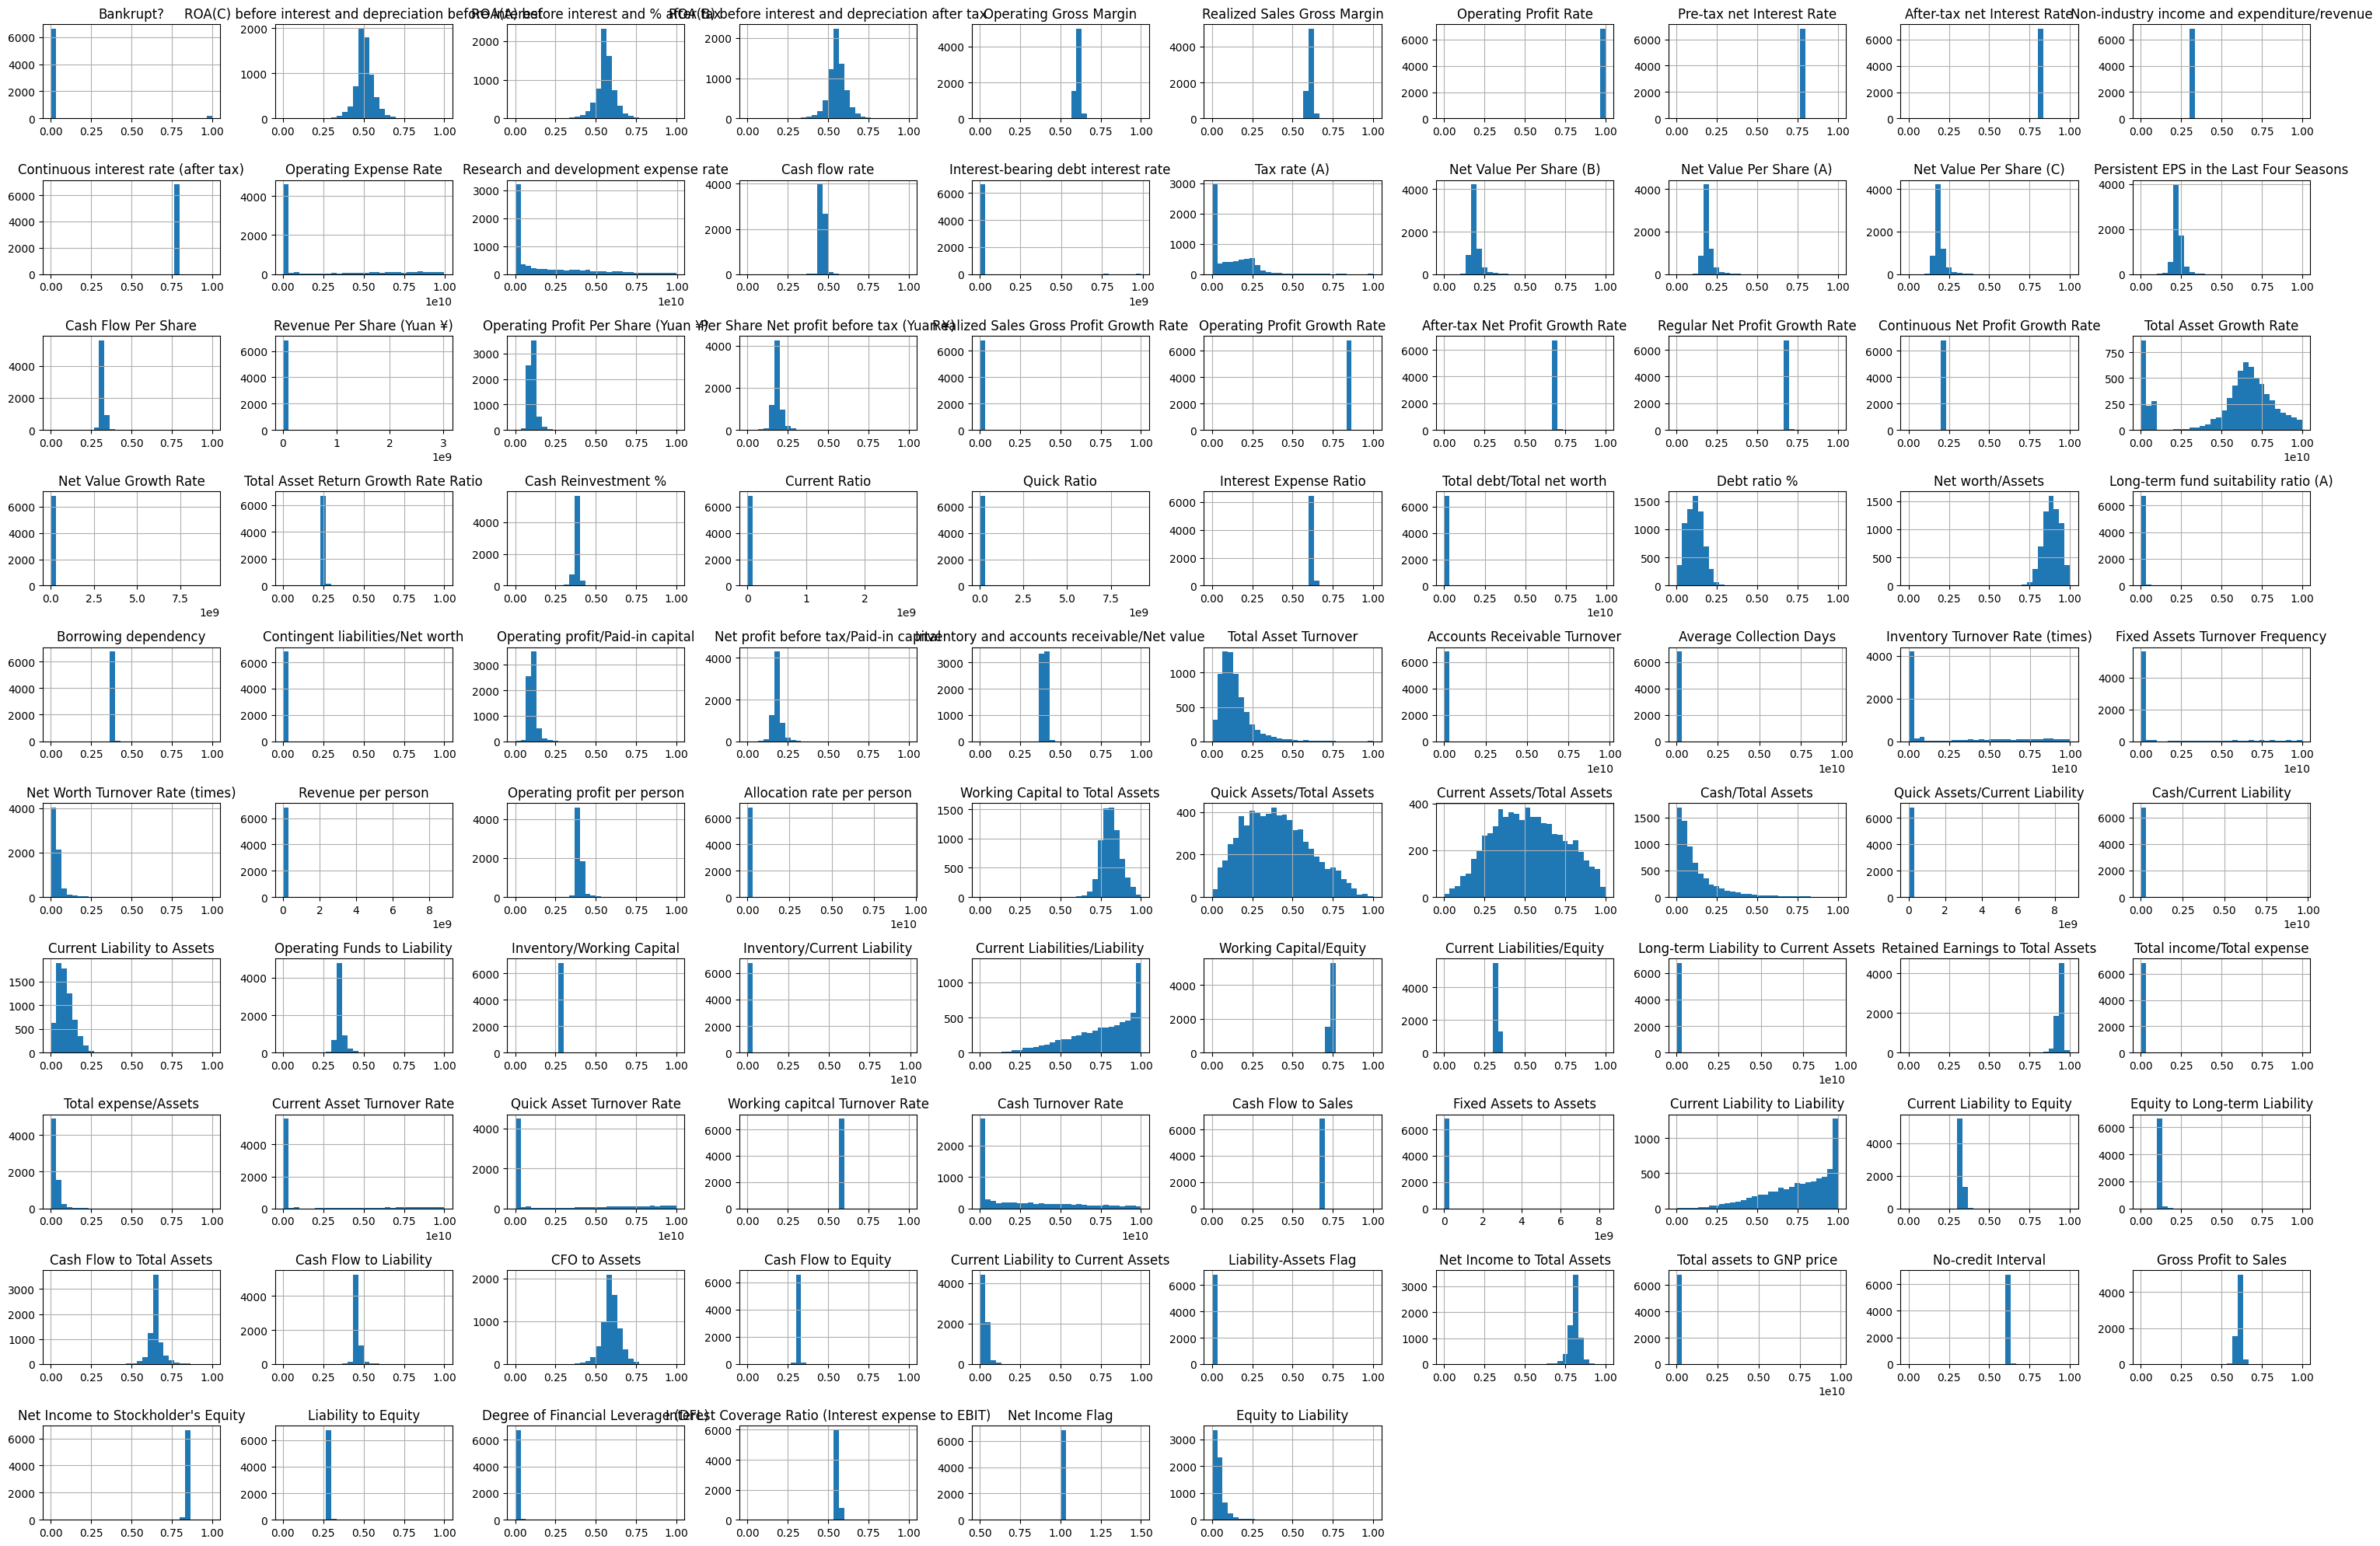

In [10]:
#checking the histograms of the data
num_columns = df.select_dtypes(include='number').columns

df[num_columns].hist(
    bins=30,
    figsize=(30,20))

plt.tight_layout()
plt.show()

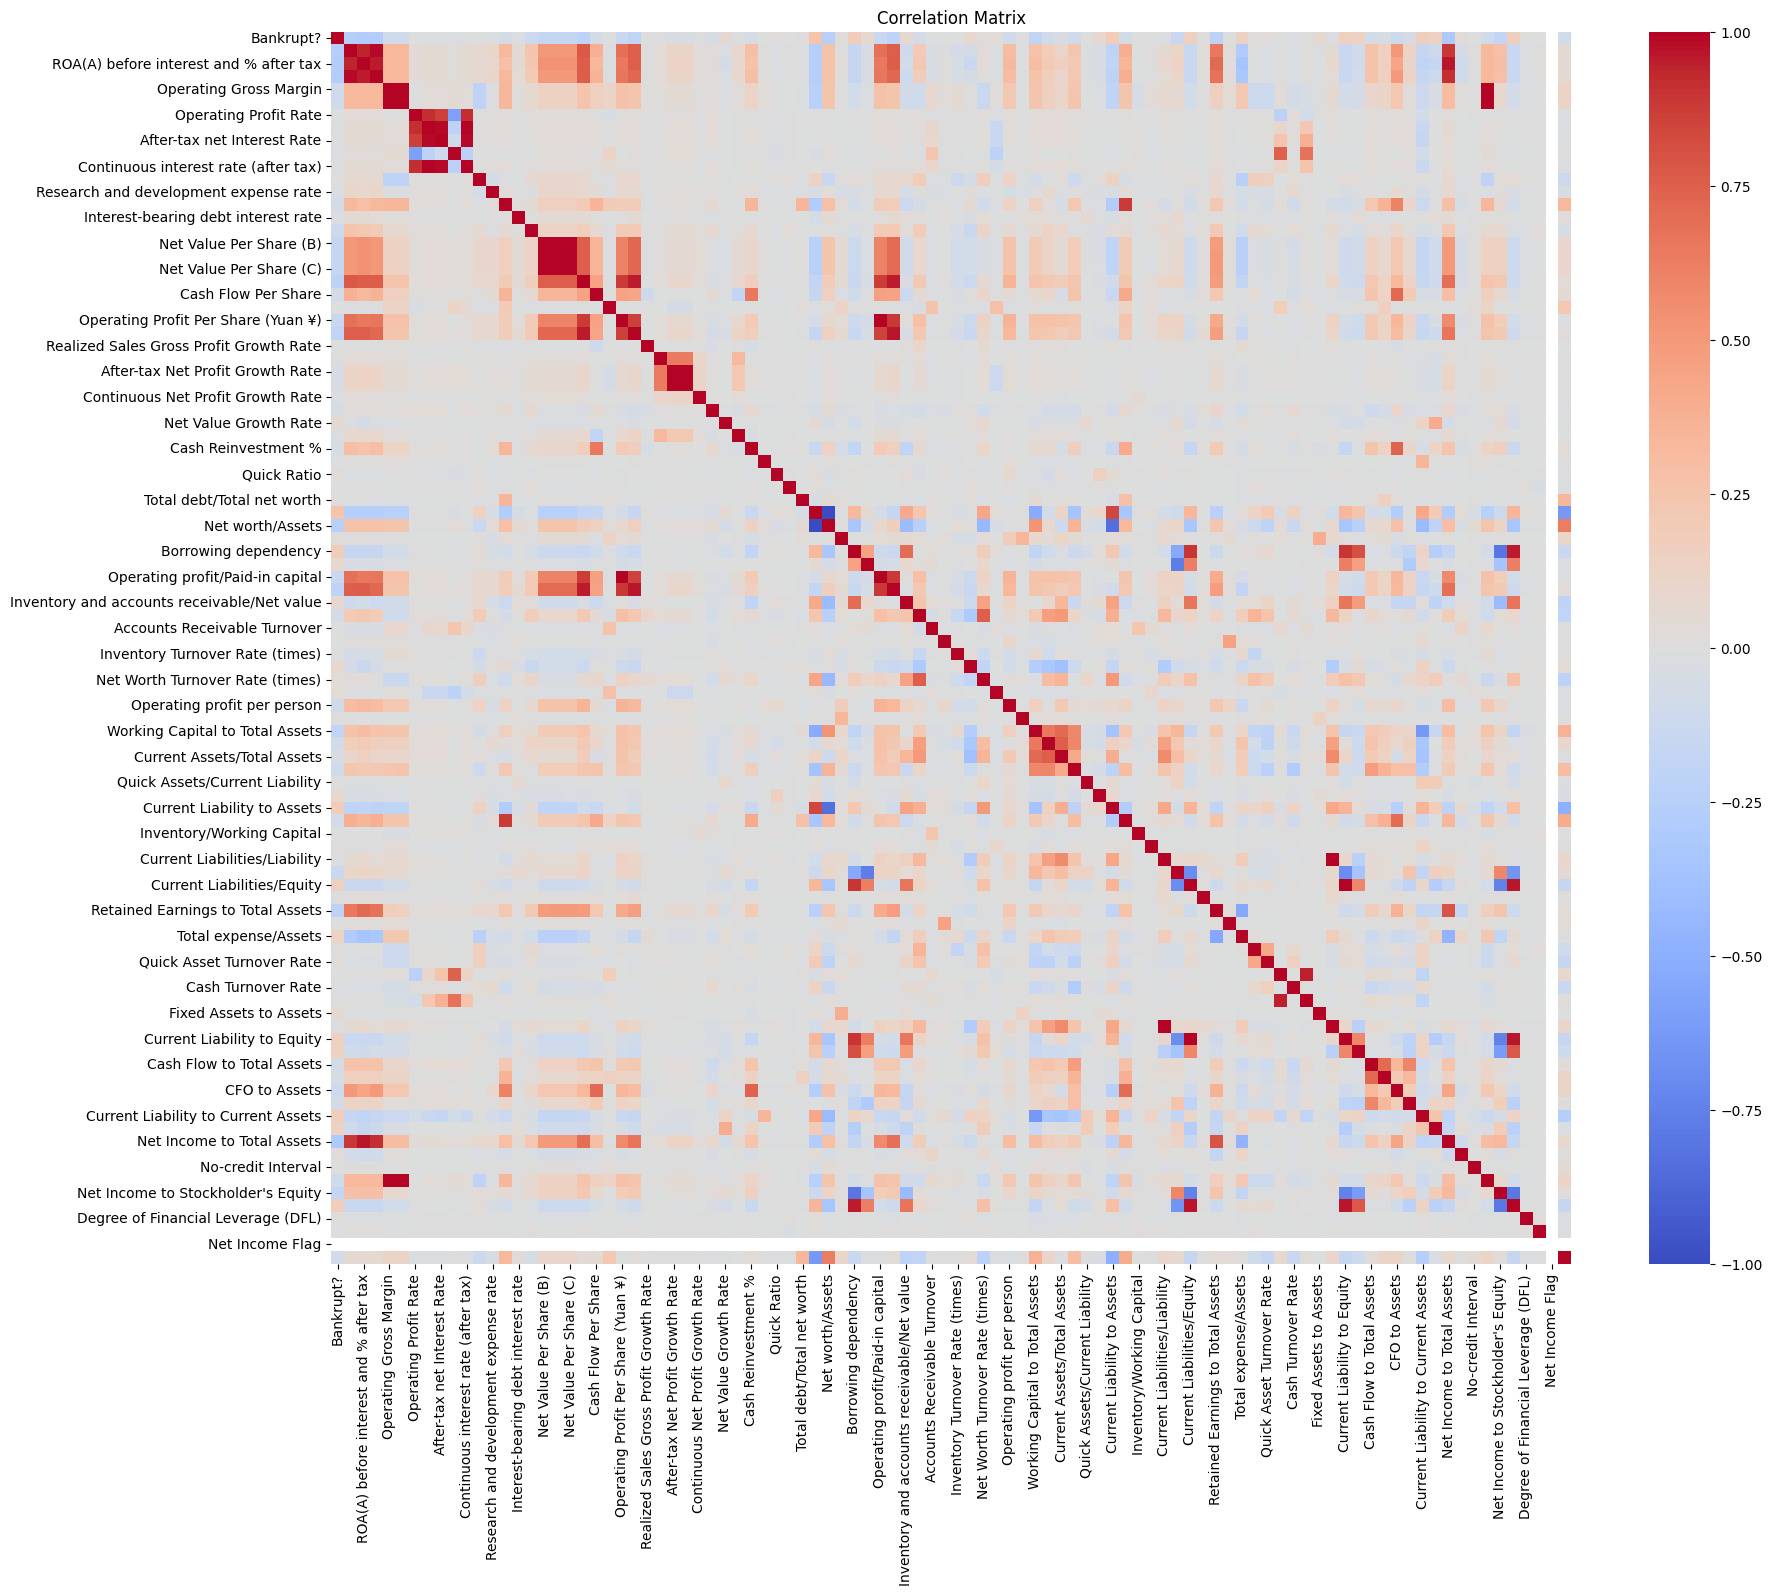

In [11]:
correlation = df[num_columns].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title("Correlation Matrix")
plt.show()

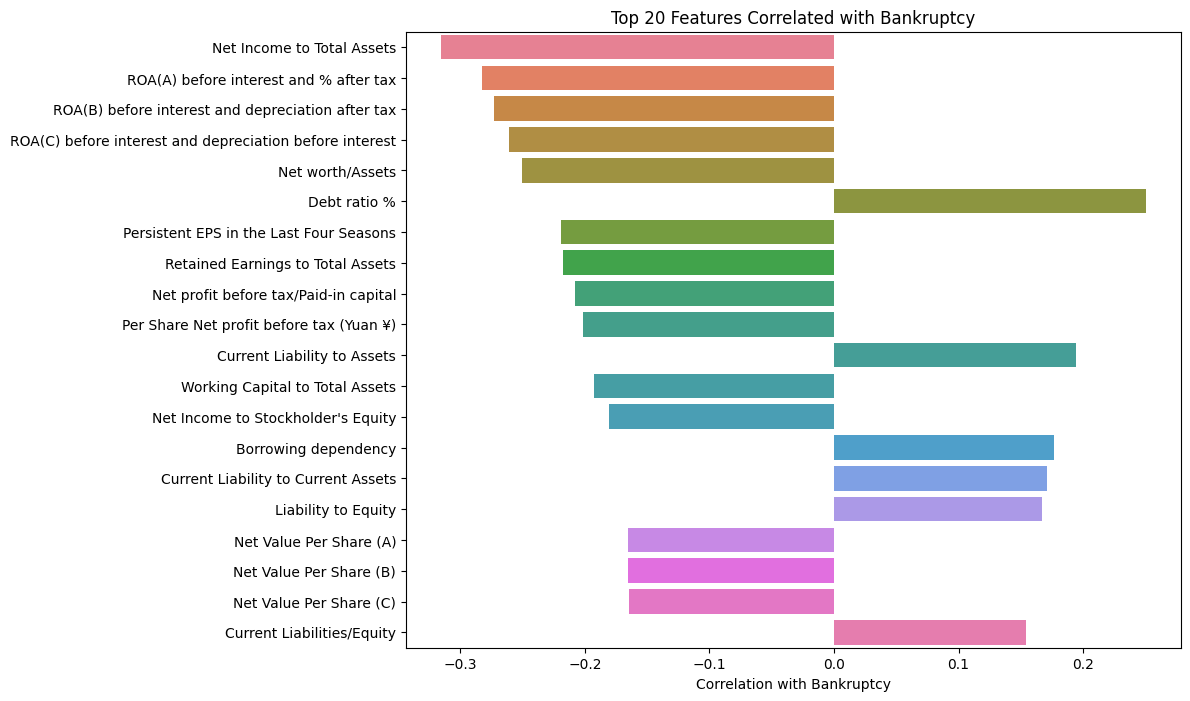

Net Income to Total Assets                                -0.315
ROA(A) before interest and % after tax                    -0.283
ROA(B) before interest and depreciation after tax         -0.273
ROA(C) before interest and depreciation before interest   -0.261
Net worth/Assets                                          -0.250
Debt ratio %                                               0.250
Persistent EPS in the Last Four Seasons                   -0.220
Retained Earnings to Total Assets                         -0.218
Net profit before tax/Paid-in capital                     -0.208
Per Share Net profit before tax (Yuan ¥)                  -0.201
Current Liability to Assets                                0.194
Working Capital to Total Assets                           -0.193
Net Income to Stockholder's Equity                        -0.181
Borrowing dependency                                       0.177
Current Liability to Current Assets                        0.171
Liability to Equity      

In [12]:
target_correlation = (
    correlation["Bankrupt?"]
    .drop("Bankrupt?")
    .sort_values(key=abs, ascending=False)
)

top_20 = target_correlation.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=top_20.values,
    y=top_20.index,
    hue=top_20.index,
    legend=False,
)

plt.xlabel("Correlation with Bankruptcy")
plt.ylabel("")
plt.title("Top 20 Features Correlated with Bankruptcy")
plt.show()
target_correlation.head(20)

Text(0.5, 1.0, 'Bankrupt vs Retained Earnings to Total Assets')

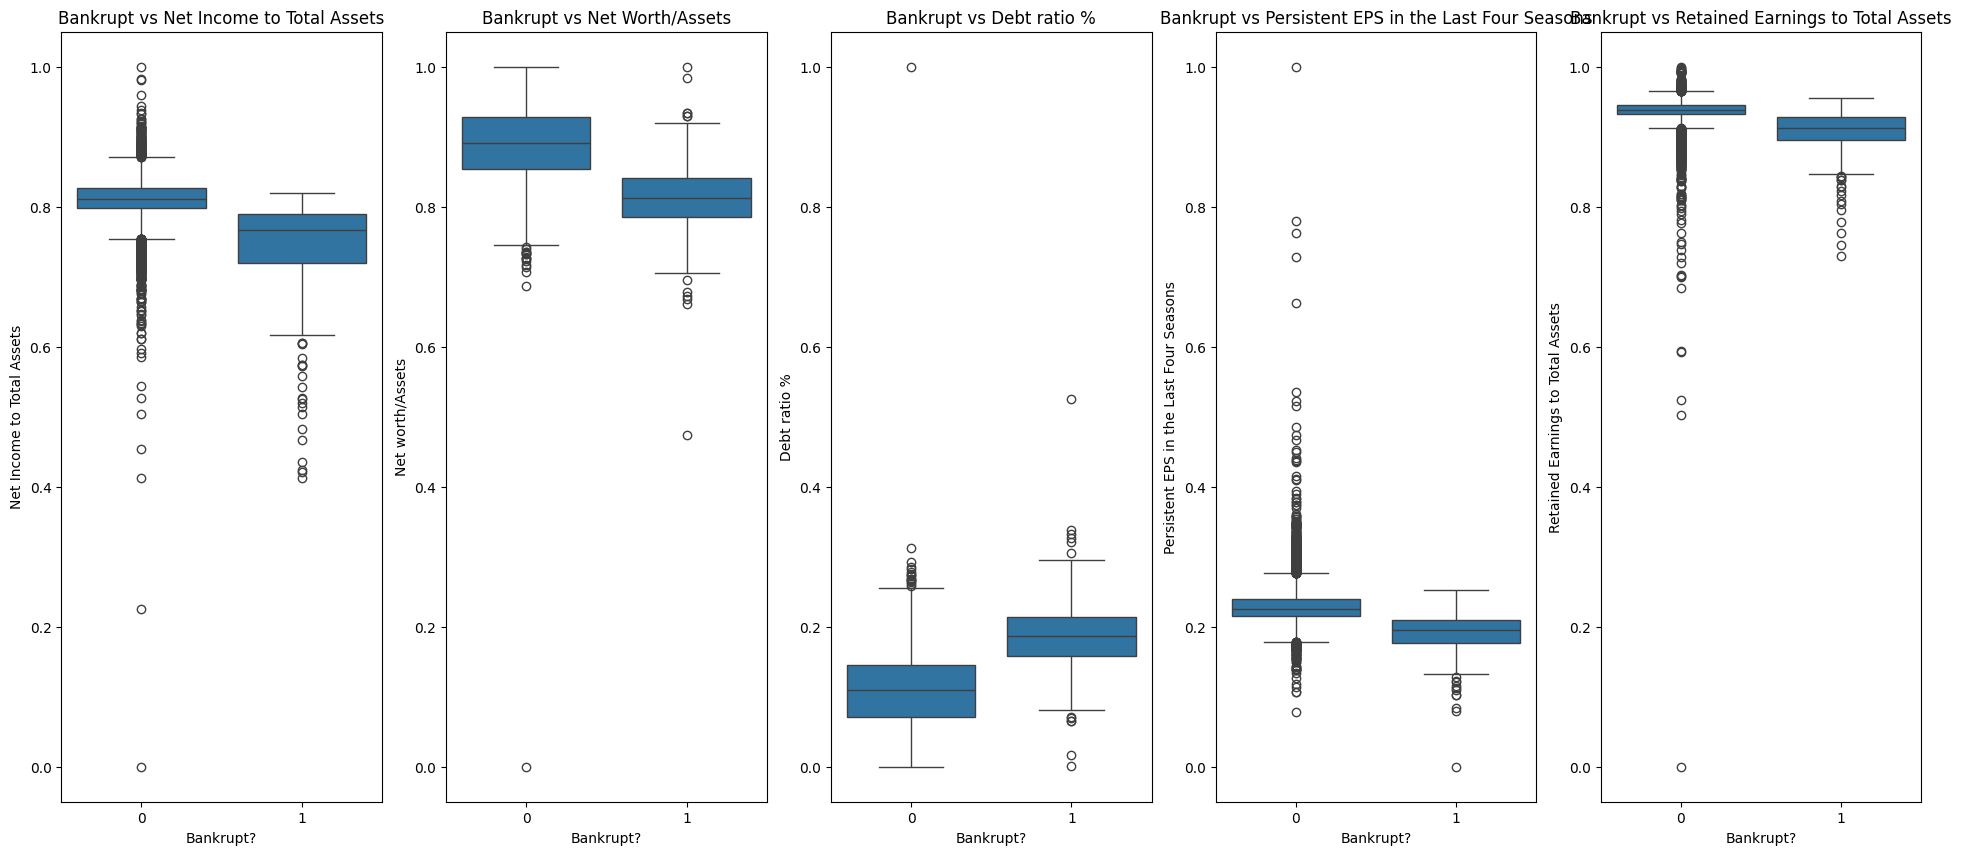

In [13]:
## now check the interesting feature

f, axes = plt.subplots(ncols=5, figsize=(24,10))

sns.boxplot(x='Bankrupt?', y='Net Income to Total Assets', data=df, ax=axes[0])
axes[0].set_title('Bankrupt vs Net Income to Total Assets')

sns.boxplot(x='Bankrupt?', y='Net worth/Assets', data=df, ax=axes[1])
axes[1].set_title('Bankrupt vs Net Worth/Assets')

sns.boxplot(x='Bankrupt?', y='Debt ratio %', data=df, ax=axes[2])
axes[2].set_title('Bankrupt vs Debt ratio %')

sns.boxplot(x='Bankrupt?', y='Persistent EPS in the Last Four Seasons', data=df, ax=axes[3])
axes[3].set_title('Bankrupt vs Persistent EPS in the Last Four Seasons')

sns.boxplot(x='Bankrupt?', y='Retained Earnings to Total Assets', data=df, ax=axes[4])
axes[4].set_title('Bankrupt vs Retained Earnings to Total Assets')

In [46]:
## Handle mixed scale columns

df_model = df.copy()

mixed_scale_columns = [
    'Operating Expense Rate', 'Research and development expense rate', 'Interest-bearing debt interest rate', 'Total Asset Growth Rate',
    'Inventory Turnover Rate (times)','Fixed Assets Turnover Frequency','Inventory/Current Liability','Current Asset Turnover Rate',
    'Quick Asset Turnover Rate', 'Cash Turnover Rate','Average Collection Days','Total assets to GNP price'

]

invalid_ratio_columns = [
    'Revenue Per Share (Yuan ¥)','Net Value Growth Rate','Current Ratio','Quick Ratio','Total debt/Total net worth',
    'Accounts Receivable Turnover','Revenue per person','Allocation rate per person',
    'Quick Assets/Current Liability','Long-term Liability to Current Assets', 'Fixed Assets to Assets','Cash/Current Liability'
]

df_model = df.drop(columns=mixed_scale_columns)

extreme_counts = (
    df_model[invalid_ratio_columns]
    .ge(1_000_000)
    .sum()
    .sort_values(ascending=False)
)

display(extreme_counts)

#remove that invalid column ratio
df_model[invalid_ratio_columns] = (
    df_model[invalid_ratio_columns]
    .mask(df_model[invalid_ratio_columns] >= 1_000_000)
)

Long-term Liability to Current Assets    109
Cash/Current Liability                    46
Accounts Receivable Turnover              22
Allocation rate per person                12
Quick Ratio                                9
Total debt/Total net worth                 8
Revenue Per Share (Yuan ¥)                 5
Quick Assets/Current Liability             3
Revenue per person                         2
Net Value Growth Rate                      2
Current Ratio                              1
Fixed Assets to Assets                     1
dtype: int64

In [51]:
#check the invalid column ratio value distributions
df_model[invalid_ratio_columns].describe()

,Revenue Per Share (Yuan ¥),Net Value Growth Rate,Current Ratio,Quick Ratio,Total debt/Total net worth,Accounts Receivable Turnover,Revenue per person,Allocation rate per person,Quick Assets/Current Liability,Long-term Liability to Current Assets,Fixed Assets to Assets,Cash/Current Liability
count,6814.000,6817.000,6818.000,6810.000,6811.000,6797.000,6817.000,6807.000,6816.000,6710.000,6818.000,6773.000
mean,0.039,0.001,0.015,0.011,0.008,0.002,0.036,0.016,0.012,0.007,0.249,0.013
std,0.045,0.012,0.024,0.018,0.020,0.016,0.056,0.040,0.019,0.020,0.200,0.032
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.016,0.000,0.008,0.005,0.003,0.001,0.010,0.004,0.005,0.000,0.085,0.002
50%,0.027,0.000,0.011,0.007,0.006,0.001,0.019,0.008,0.008,0.002,0.197,0.005
75%,0.046,0.000,0.016,0.012,0.009,0.001,0.036,0.015,0.013,0.008,0.372,0.012
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [52]:
df_model.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Cash flow rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Working capitcal Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6814.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6817.000,6819.000,6819.000,6818.000,6810.000,6819.000,6811.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6797.000,6819.000,6817.000,6819.000,6807.000,6819.000,6819.000,6819.000,6819.000,6816.000,6773.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6710.000,6819.000,6819.000,6819.000,6819.000,6819.000,6818.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000,6819.000
mean,0.032,0.505,0.559,0.554,0.608,0.608,0.999,0.797,0.809,0.304,0.781,0.467,0.115,0.191,0.191,0.191,0.229,0.323,0.039,0.109,0.184,0.022,0.848,0.689,0.689,0.218,0.001,0.264,0.380,0.015,0.011,0.631,0.008,0.113,0.887,0.009,0.375,0.006,0.109,0.183,0.402,0.142,0.002,0.039,0.036,0.401,0.016,0.814,0.400,0.522,0.124,0.012,0.013,0.091,0.354,0.277,0.762,0.736,0.331,0.007,0.935,0.003,0.029,0.594,0.672,0.249,0.762,0.331,0.116,0.650,0.462,0.593,0.316,0.032,0.001,0.808,0.624,0.608,0.840,0.280,0.028,0.565,1.000,0.048
std,0.177,0.061,0.066,0.062,0.017,0.017,0.013,0.013,0.014,0.011,0.013,0.017,0.139,0.033,0.033,0.033,0.033,0.018,0.045,0.028,0.033,0.012,0.011,0.014,0.014,0.010,0.012,0.010,0.021,0.024,0.018,0.011,0.020,0.054,0.054,0.028,0.016,0.012,0.028,0.031,0.013,0.101,0.016,0.037,0.056,0.033,0.040,0.059,0.202,0.218,0.139,0.019,0.032,0.050,0.035,0.010,0.207,0.012,0.013,0.020,0.026,0.012,0.027,0.009,0.009,0.20

Now the distribution across the invalid column ratios looks good

In [48]:
df_model.to_csv(r'data\raw\company_bankruptcy\data_model.csv', index=0)

## Modeling

In [12]:
df_model = pd.read_csv(r'data\raw\company_bankruptcy\data_model.csv')

X = df_model.drop(columns=[config.target_column])
y = df_model[config.target_column]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.test_size, random_state=config.seed
)

In [14]:
#modeling with RandomForest

rf_pipeline = make_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced",
        random_state=config.seed,
        n_jobs=1
    )
)

# Parameters to test
rf_parameters = {
    "randomforestclassifier__n_estimators": [200, 400],
    "randomforestclassifier__max_depth": [8, 12, 16, None],
    "randomforestclassifier__min_samples_leaf": [2, 5, 10],
    "randomforestclassifier__max_features": ["sqrt", 0.5],
    "randomforestclassifier__bootstrap": [True],
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=config.seed,
)

search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_parameters,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=config.seed,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


search_rf.fit(X_train, y_train)

best_index = search_rf.best_index_

train_cv_score = search_rf.cv_results_[
    "mean_train_score"
][best_index]

validation_cv_score = search_rf.cv_results_[
    "mean_test_score"
][best_index]

validation_cv_std = search_rf.cv_results_[
    "std_test_score"
][best_index]

print(f"Mean training PR-AUC: {train_cv_score:.3f}")
print(f"Mean CV PR-AUC: {validation_cv_score:.3f}")
print(f"CV standard deviation: {validation_cv_std:.3f}")


print("Best parameters:")
print(search_rf.best_params_)

print(f"Best CV PR-AUC: {search_rf.best_score_:.3f}")

model_rf = search_rf.best_estimator_

y_pred = model_rf.predict(X_test)
y_proba = model_rf.predict_proba(X_test)[:,1]

print(f"ROC-AUC scores : {roc_auc_score(y_test, y_proba)}")
print(f"Precision scores : {precision_score(y_test, y_pred)}")
print(f"PR-AUC:", {average_precision_score(y_test, y_proba)})
print(f"Recall: {recall_score(y_test, y_pred)}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mean training PR-AUC: 0.841
Mean CV PR-AUC: 0.417
CV standard deviation: 0.049
Best parameters:
{'randomforestclassifier__n_estimators': 200, 'randomforestclassifier__min_samples_leaf': 10, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_depth': None, 'randomforestclassifier__bootstrap': True}
Best CV PR-AUC: 0.417
ROC-AUC scores : 0.9391305646401744
Precision scores : 0.45454545454545453
PR-AUC: {0.45825724302463944}
Recall: 0.6862745098039216


In [15]:
threshold_results = []

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(y_test, y_pred_threshold),
        "predicted_bankruptcies": y_pred_threshold.sum()
    })

pd.DataFrame(threshold_results)

,threshold,precision,recall,predicted_bankruptcies
0,0.500,0.455,0.686,77
1,0.600,0.481,0.490,52
2,0.700,0.541,0.392,37
3,0.800,0.632,0.235,19
4,0.900,0.750,0.059,4


In [16]:
cv_results_df_rf = pd.DataFrame(
    search_rf.cv_results_
)

parameter_columns = [
    column
    for column in cv_results_df_rf.columns
    if column.startswith("param_")
]

candidate_result_rf = cv_results_df_rf[
    parameter_columns + [
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]
].copy()

candidate_result_rf.columns = [
    column
    .replace("param_xgbclassifier__", "")
    .replace("param_", "")
    for column in candidate_result_rf.columns
]

candidate_result_rf = candidate_result_rf.sort_values(
    "rank_test_score"
).reset_index(drop=True)

candidate_result_rf['train_test_gap'] = abs(candidate_result_rf['mean_train_score'] - candidate_result_rf['mean_test_score'])

display(
    candidate_result_rf)

,randomforestclassifier__n_estimators,randomforestclassifier__min_samples_leaf,randomforestclassifier__max_features,randomforestclassifier__max_depth,randomforestclassifier__bootstrap,mean_train_score,mean_test_score,std_test_score,rank_test_score,train_test_gap
0,200,10,sqrt,None,True,0.841,0.417,0.049,1,0.424
1,200,10,sqrt,8,True,0.787,0.411,0.051,2,0.376
2,200,5,sqrt,16,True,0.966,0.408,0.056,3,0.558
3,400,5,sqrt,16,True,0.967,0.406,0.053,4,0.561
4,400,2,sqrt,None,True,1.000,0.399,0.058,5,0.601
5,200,2,sqrt,12,True,0.880,0.392,0.050,6,0.489
6,400,2,sqrt,16,True,0.966,0.390,0.055,7,0.576
7,200,2,sqrt,16,True,0.966,0.388,0.059,8,0.578
8,400,2,0.500,12,True,0.778,0.377,0.049,9,0.402
9,400,2,0.500,None,True,1.000,0.375,0.047,10,0.625


In [17]:
%%time
# modeling with xgboost

# Weight for the minority bankruptcy class
scale_pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

print("Scale positive weight:", scale_pos_weight)

model_xb = make_pipeline(
    xb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        tree_method='hist',
        random_state=config.seed,
        n_jobs=1
    )
)

# Parameters to test
parameter_grid_xb = {
    "xgbclassifier__n_estimators": [100, 200, 300],
    "xgbclassifier__learning_rate": [0.01, 0.05],
    "xgbclassifier__max_depth": [2, 3, 4],
    "xgbclassifier__min_child_weight": [1, 3, 5],
    "xgbclassifier__subsample": [0.6, 0.8],
    "xgbclassifier__colsample_bytree": [0.6, 0.8],
    "xgbclassifier__reg_alpha": [1,2,5],
    "xgbclassifier__reg_lambda": [2,5,10],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=config.seed,
)

search_xb = RandomizedSearchCV(
    estimator=model_xb,
    param_distributions=parameter_grid_xb,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=config.seed,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


search_xb.fit(X_train, y_train)

best_index = search_xb.best_index_

train_cv_score = search_xb.cv_results_[
    "mean_train_score"
][best_index]

validation_cv_score = search_xb.cv_results_[
    "mean_test_score"
][best_index]

validation_cv_std = search_xb.cv_results_[
    "std_test_score"
][best_index]

print(f"Mean training PR-AUC: {train_cv_score:.3f}")
print(f"Mean CV PR-AUC: {validation_cv_score:.3f}")
print(f"CV standard deviation: {validation_cv_std:.3f}")

print("Best parameters:")
print(search_xb.best_params_)

model_xb = search_xb.best_estimator_

y_pred_xb = model_xb.predict(X_test)
y_proba_xb = model_xb.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xb):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_xb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_xb):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_xb):.3f}")

Scale positive weight: 31.27810650887574
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mean training PR-AUC: 0.587
Mean CV PR-AUC: 0.420
CV standard deviation: 0.040
Best parameters:
{'xgbclassifier__subsample': 0.6, 'xgbclassifier__reg_lambda': 10, 'xgbclassifier__reg_alpha': 5, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__min_child_weight': 5, 'xgbclassifier__max_depth': 3, 'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__colsample_bytree': 0.8}
ROC-AUC: 0.932
PR-AUC: 0.441
Precision: 0.234
Recall: 0.784
CPU times: total: 1.39 s
Wall time: 10.9 s


In [18]:
threshold_results = []

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_threshold = (y_proba_xb >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(y_test, y_pred_threshold),
        "predicted_bankruptcies": y_pred_threshold.sum()
    })

pd.DataFrame(threshold_results)

,threshold,precision,recall,predicted_bankruptcies
0,0.500,0.234,0.784,171
1,0.600,0.275,0.745,138
2,0.700,0.324,0.706,111
3,0.800,0.446,0.647,74
4,0.900,0.586,0.333,29


In [19]:
cv_results_df = pd.DataFrame(
    search_xb.cv_results_
)

parameter_columns = [
    column
    for column in cv_results_df.columns
    if column.startswith("param_")
]

candidate_result_xb = cv_results_df[
    parameter_columns + [
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]
].copy()

candidate_result_xb.columns = [
    column
    .replace("param_xgbclassifier__", "")
    .replace("param_", "")
    for column in candidate_result_xb.columns
]

candidate_result_xb = candidate_result_xb.sort_values(
    "rank_test_score"
).reset_index(drop=True)

candidate_result_xb['train_test_gap'] = abs(candidate_result_xb['mean_train_score'] - candidate_result_xb['mean_test_score'])

display(
    candidate_result_xb)

,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,mean_train_score,mean_test_score,std_test_score,rank_test_score,train_test_gap
0,0.600,10,5,300,5,3,0.010,0.800,0.587,0.420,0.040,1,0.167
1,0.600,2,1,200,1,3,0.050,0.800,0.920,0.416,0.038,2,0.505
2,0.600,5,5,300,1,4,0.050,0.600,0.999,0.403,0.032,3,0.595
3,0.800,2,1,100,1,2,0.050,0.800,0.570,0.401,0.042,4,0.169
4,0.600,5,5,300,3,3,0.050,0.800,0.960,0.398,0.035,5,0.562
5,0.600,5,5,300,5,2,0.010,0.800,0.495,0.390,0.043,6,0.105
6,0.600,10,2,300,5,2,0.010,0.800,0.494,0.388,0.043,7,0.106
7,0.600,2,1,200,3,2,0.010,0.800,0.479,0.386,0.033,8,0.093
8,0.800,5,5,100,5,2,0.010,0.800,0.412,0.350,0.046,9,0.062
9,0.800,2,5,100,5,2,0.010,0.600,0.402,0.347,0.046,10,0.055


In [20]:
%%time

# Modeling with LightGBM

scale_pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

print("Scale positive weight:", scale_pos_weight)

model_lgbm = make_pipeline(
    lgb.LGBMClassifier(
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=config.seed,
        n_jobs=1,
        force_col_wise=True,
        verbosity=-1,
    )
)

parameter_grid_lgbm = {
    "lgbmclassifier__n_estimators": [100, 200, 300, 500],
    "lgbmclassifier__learning_rate": [0.01, 0.03, 0.05],
    "lgbmclassifier__max_depth": [3, 5, 7],
    "lgbmclassifier__num_leaves": [7, 15, 31],
    "lgbmclassifier__min_child_samples": [10, 20, 40, 80],
    "lgbmclassifier__subsample": [0.6, 0.8, 1.0],
    "lgbmclassifier__subsample_freq": [1],
    "lgbmclassifier__colsample_bytree": [0.6, 0.8, 1.0],
    "lgbmclassifier__reg_alpha": [1, 2, 5],
    "lgbmclassifier__reg_lambda": [2, 5, 10],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=config.seed,
)

search_lgbm = RandomizedSearchCV(
    estimator=model_lgbm,
    param_distributions=parameter_grid_lgbm,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=config.seed,

    # Run CV sequentially to prevent Windows native-memory crashes
    n_jobs=1,
    pre_dispatch=1,

    verbose=1,
    return_train_score=True,
    error_score="raise",
)

search_lgbm.fit(X_train, y_train)

best_index = search_lgbm.best_index_

train_cv_score = search_lgbm.cv_results_[
    "mean_train_score"
][best_index]

validation_cv_score = search_lgbm.cv_results_[
    "mean_test_score"
][best_index]

validation_cv_std = search_lgbm.cv_results_[
    "std_test_score"
][best_index]

print(f"Mean training PR-AUC: {train_cv_score:.3f}")
print(f"Mean CV PR-AUC: {validation_cv_score:.3f}")
print(f"CV standard deviation: {validation_cv_std:.3f}")
print(
    f"Train-CV gap: "
    f"{train_cv_score - validation_cv_score:.3f}"
)

print("Best parameters:")
print(search_lgbm.best_params_)

model_lgbm = search_lgbm.best_estimator_

y_pred_lgbm = model_lgbm.predict(X_test)
y_proba_lgbm = model_lgbm.predict_proba(X_test)[:, 1]

print(
    f"ROC-AUC: "
    f"{roc_auc_score(y_test, y_proba_lgbm):.3f}"
)

print(
    f"PR-AUC: "
    f"{average_precision_score(y_test, y_proba_lgbm):.3f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, y_pred_lgbm):.3f}"
)

print(
    f"Recall: "
    f"{recall_score(y_test, y_pred_lgbm):.3f}"
)

Scale positive weight: 31.27810650887574
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mean training PR-AUC: 0.948
Mean CV PR-AUC: 0.419
CV standard deviation: 0.031
Train-CV gap: 0.529
Best parameters:
{'lgbmclassifier__subsample_freq': 1, 'lgbmclassifier__subsample': 0.8, 'lgbmclassifier__reg_lambda': 2, 'lgbmclassifier__reg_alpha': 1, 'lgbmclassifier__num_leaves': 15, 'lgbmclassifier__n_estimators': 200, 'lgbmclassifier__min_child_samples': 80, 'lgbmclassifier__max_depth': 5, 'lgbmclassifier__learning_rate': 0.03, 'lgbmclassifier__colsample_bytree': 0.6}
ROC-AUC: 0.939
PR-AUC: 0.499
Precision: 0.373
Recall: 0.745
CPU times: total: 25.1 s
Wall time: 25.3 s


In [21]:
threshold_results = []

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_threshold = (y_proba_lgbm >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(y_test, y_pred_threshold),
        "predicted_bankruptcies": y_pred_threshold.sum()
    })

pd.DataFrame(threshold_results)

,threshold,precision,recall,predicted_bankruptcies
0,0.500,0.373,0.745,102
1,0.600,0.404,0.706,89
2,0.700,0.459,0.667,74
3,0.800,0.519,0.549,54
4,0.900,0.633,0.373,30


In [22]:
cv_results_df = pd.DataFrame(
    search_lgbm.cv_results_
)

parameter_columns = [
    column
    for column in cv_results_df.columns
    if column.startswith("param_")
]

candidate_result_lgbm = cv_results_df[
    parameter_columns + [
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]
].copy()

candidate_result_lgbm.columns = [
    column
    .replace("param_lgbmclassifier__", "")
    .replace("param_", "")
    for column in candidate_result_lgbm.columns
]

candidate_result_lgbm = candidate_result_lgbm.sort_values(
    "rank_test_score"
).reset_index(drop=True)

candidate_result_lgbm['train_test_gap'] = abs(candidate_result_lgbm['mean_train_score'] - candidate_result_lgbm['mean_test_score'])

display(
    candidate_result_lgbm)

,subsample_freq,subsample,reg_lambda,reg_alpha,num_leaves,n_estimators,min_child_samples,max_depth,learning_rate,colsample_bytree,mean_train_score,mean_test_score,std_test_score,rank_test_score,train_test_gap
0,1,0.800,2,1,15,200,80,5,0.030,0.600,0.948,0.419,0.031,1,0.529
1,1,0.800,10,5,7,500,40,7,0.050,0.600,0.998,0.410,0.045,2,0.588
2,1,0.600,5,2,31,200,20,3,0.030,0.800,0.757,0.407,0.038,3,0.351
3,1,0.600,5,1,7,300,80,5,0.010,0.600,0.625,0.398,0.030,4,0.226
4,1,1.000,5,5,15,300,40,3,0.010,0.600,0.619,0.398,0.026,5,0.221
5,1,0.800,5,2,15,200,40,3,0.010,0.600,0.575,0.397,0.021,6,0.178
6,1,0.600,2,1,7,500,10,3,0.030,0.800,0.991,0.396,0.040,7,0.594
7,1,1.000,2,1,7,100,10,5,0.030,0.800,0.675,0.393,0.023,8,0.282
8,1,1.000,2,2,7,500,80,5,0.050,0.800,1.000,0.386,0.051,9,0.614
9,1,1.000,2,2,31,100,20,5,0.010,0.600,0.669,0.351,0.039,10,0.317


In [23]:
%%time

# Final selected LightGBM model: CV rank 6

scale_pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

print("Scale positive weight:", scale_pos_weight)

model_lgbm = make_pipeline(
    lgb.LGBMClassifier(
        objective="binary",
        scale_pos_weight=scale_pos_weight,

        # Selected rank-6 parameters
        n_estimators=200,
        learning_rate=0.01,
        max_depth=3,
        num_leaves=15,
        min_child_samples=40,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.6,
        reg_alpha=2,
        reg_lambda=5,

        # Reproducibility and stability
        random_state=config.seed,
        n_jobs=1,
        force_col_wise=True,
        verbosity=-1,
    )
)

# Fit on the complete training set
model_lgbm.fit(X_train, y_train)

# Test-set predictions
y_pred_lgbm = model_lgbm.predict(X_test)
y_proba_lgbm = model_lgbm.predict_proba(X_test)[:, 1]

print(
    f"ROC-AUC: "
    f"{roc_auc_score(y_test, y_proba_lgbm):.3f}"
)

print(
    f"PR-AUC: "
    f"{average_precision_score(y_test, y_proba_lgbm):.3f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, y_pred_lgbm):.3f}"
)

print(
    f"Recall: "
    f"{recall_score(y_test, y_pred_lgbm):.3f}"
)

Scale positive weight: 31.27810650887574
ROC-AUC: 0.933
PR-AUC: 0.438
Precision: 0.258
Recall: 0.765
CPU times: total: 328 ms
Wall time: 332 ms


In [26]:
## compare the model
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Change variable names here if yours are different
models = {
    "Random Forest": model_rf,
    "XGBoost": model_xb,
    "LightGBM": model_lgbm,
}

threshold = 0.50

results = []
model_predictions = {}

for model_name, model in models.items():

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    results.append({
        "Model": model_name,

        # Threshold-independent ranking metrics
        "PR-AUC": average_precision_score(
            y_test,
            y_proba,
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_proba,
        ),

        # Metrics at threshold = 0.50
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "F2": fbeta_score(
            y_test,
            y_pred,
            beta=2,
            zero_division=0,
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred,
        ),
        "Accuracy": accuracy_score(
            y_test,
            y_pred,
        ),
        "MCC": matthews_corrcoef(
            y_test,
            y_pred,
        ),
        "NPV": negative_predictive_value,

        # Probability-quality metrics: lower is better
        "Log Loss": log_loss(
            y_test,
            y_proba,
        ),
        "Brier Score": brier_score_loss(
            y_test,
            y_proba,
        ),

        # Confusion matrix
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

    model_predictions[model_name] = {
        "predicted_class": y_pred,
        "predicted_probability": y_proba,
    }

comparison = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("PR-AUC", ascending=False)
)

comparison.reset_index()

,Model,PR-AUC,ROC-AUC,Precision,Recall,Specificity,F1,F2,Balanced Accuracy,Accuracy,MCC,NPV,Log Loss,Brier Score,TN,FP,FN,TP
0,Random Forest,0.458,0.939,0.455,0.686,0.968,0.547,0.623,0.827,0.957,0.538,0.988,0.122,0.035,1271,42,16,35
1,XGBoost,0.441,0.932,0.234,0.784,0.900,0.360,0.533,0.842,0.896,0.392,0.991,0.245,0.074,1182,131,11,40
2,LightGBM,0.438,0.933,0.258,0.765,0.915,0.386,0.549,0.840,0.909,0.411,0.990,0.197,0.061,1201,112,12,39


## Model Comparison Summary

Three classification models were evaluated using stratified 5-fold cross-validation and an independent test set. Because bankruptcy is highly imbalanced, **PR-AUC** was used as the primary evaluation metric.

| Metric | Random Forest | XGBoost | LightGBM |
|---|---:|---:|---:|
| Training PR-AUC | 0.841 | 0.587 | 0.575 |
| CV PR-AUC | 0.417 | **0.420** | 0.397 |
| Test PR-AUC | **0.458** | 0.441 | 0.438 |
| Test ROC-AUC | **0.939** | 0.932 | 0.933 |
| Precision | **0.455** | 0.234 | 0.258 |
| Recall | 0.686 | **0.784** | 0.765 |
| F1-score | **0.547** | 0.360 | 0.386 |
| F2-score | **0.623** | 0.533 | 0.549 |
| MCC | **0.538** | 0.392 | 0.411 |
| False positives | **42** | 131 | 112 |
| False negatives | 16 | **11** | 12 |


- **Random Forest** achieved the best test PR-AUC, ROC-AUC, precision, F1-score, F2-score, and MCC.
- **XGBoost** achieved the highest recall and had the smallest training–validation gap, but it generated substantially more false positives.
- **LightGBM** provided an intermediate result but did not outperform Random Forest or XGBoost on their primary strengths.
- Random Forest detected 35 of 51 bankruptcies and generated 42 false positives.
- XGBoost detected five additional bankruptcies but generated 89 additional false positives.
- The three CV PR-AUC scores were relatively similar, so there was no decisive cross-validation winner.

### Final Model Selection

**Random Forest was selected as the final model** because it provided the strongest overall test performance and the best balance between precision and recall.

Although Random Forest had a large training–validation gap, its CV PR-AUC of 0.417 and test PR-AUC of 0.458 were reasonably consistent. This suggests that cross-validation provided a realistic estimate of its generalization performance.

If higher recall is required, the Random Forest classification threshold can be lowered using out-of-fold validation predictions. The test set should remain untouched during threshold selection.

In [32]:
from pathlib import Path
import joblib
from datetime import datetime, timezone
import sklearn
import json

artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

model_path = artifact_dir / "random_forest_model.joblib"
params_path = artifact_dir / "random_forest_metadata.json"

# Classification threshold used during evaluation
threshold = 0.50

# Recalculate predictions from the final fitted model
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= threshold).astype(int)

# Extract the fitted Random Forest parameters
rf_estimator = model_rf.named_steps[
    "randomforestclassifier"
]

rf_params = rf_estimator.get_params(deep=False)

# Save useful metadata
metadata = {
    "model_name": "Random Forest",
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "classification_threshold": threshold,
    "positive_class": 1,
    "sklearn_version": sklearn.__version__,
    "parameters": rf_params,
    "test_metrics": {
        "roc_auc": roc_auc_score(
            y_test,
            y_proba_rf,
        ),
        "pr_auc": average_precision_score(
            y_test,
            y_proba_rf,
        ),
        "precision": precision_score(
            y_test,
            y_pred_rf,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            y_pred_rf,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test,
            y_pred_rf,
            zero_division=0,
        ),
    },
    "feature_names": (
        [str(column) for column in X_train.columns]
        if hasattr(X_train, "columns")
        else None
    ),
}


def json_converter(value):
    """Convert NumPy objects into JSON-compatible values."""

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    return str(value)


# Save the complete fitted pipeline
joblib.dump(
    model_rf,
    model_path,
    compress=3,
)

# Save parameters and metadata
with params_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=4,
        default=json_converter,
    )

print(f"Model saved to: {model_path.resolve()}")
print(f"Metadata saved to: {params_path.resolve()}")

Model saved to: D:\Modeling\default_prediction\artifacts\random_forest_model.joblib
Metadata saved to: D:\Modeling\default_prediction\artifacts\random_forest_metadata.json
